# FireMap — 화재 안전 취약지역 예측 모델

**목표**: 서울 426개 행정동의 화재 위험도 예측 및 취약지역 식별  
**Y값**: 생활인구 1만명당 연평균 화재 건수 (2021-2023)  
**모델**: Random Forest (최종 선택)

## 분석 전략

| 피처셋 | 구성 | R² | 목적 |
|--------|------|-----|------|
| A. 구조적 위험요인 | 인구+건축+상업 (비화재) | 0.09 | 취약구조 진단 |
| B. 구조적+과거피해 | A + 화재 부상·피해규모 | 0.35 | 종합 위험도 |
| C. 전체 이력 | B + 화재건수·사망 | 0.84 | 통합 위험 스코어 |

**최종 모델**: B 피처셋 — 과거 화재건수 없이도 구조적 취약성+피해심각도로 예측 (방어 가능한 R²=0.35)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import pickle, os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../models', exist_ok=True)
print('패키지 로드 완료')

패키지 로드 완료


## 1. 데이터 로드 및 전처리

In [2]:
df = pd.read_csv('../data/processed/master_table.csv', dtype={'adm_cd': str})
print(f'shape: {df.shape}')
df.head(3)

shape: (426, 13)


,adm_cd,adm_nm,fire_count,fire_death,fire_injury,fire_damage,avg_living_pop,avg_65plus_pop,ratio_65plus,multi_use_cnt,old_bldg_ratio,avg_floors,fire_rate_per_10k
0,1111053000,서울특별시 종로구 사직동,35.666667,0.666667,1.333333,35672.666667,24380.171085,3005.774569,0.1233,0.0,0.3906,2.58,14.6294
1,1111054000,서울특별시 종로구 삼청동,10.000000,0.000000,0.666667,40586.333333,5642.423065,796.863309,0.1412,0.0,0.3906,2.58,17.7229
2,1111055000,서울특별시 종로구 부암동,19.333333,0.666667,0.000000,41276.333333,14020.046855,2510.230755,0.1790,1.0,0.3906,2.58,13.7898


In [3]:
df.describe().round(3)

,fire_count,fire_death,fire_injury,fire_damage,avg_living_pop,avg_65plus_pop,ratio_65plus,multi_use_cnt,old_bldg_ratio,avg_floors,fire_rate_per_10k
count,426.000,426.000,426.000,4.260000e+02,416.000,416.000,416.000,426.000,426.000,426.000,416.000
mean,29.897,0.200,1.543,1.527580e+05,24332.185,3607.768,0.157,0.258,0.591,3.646,12.930
std,17.842,0.356,1.655,1.174679e+06,12456.598,1538.240,0.035,1.424,0.091,1.021,4.840
min,3.500,0.000,0.000,8.690000e+02,4538.291,687.241,0.067,0.000,0.391,2.580,2.973
25%,19.000,0.000,0.667,3.195717e+04,16093.538,2508.283,0.133,0.000,0.554,3.100,9.668
50%,26.333,0.000,1.000,5.186150e+04,21332.170,3326.947,0.160,0.000,0.599,3.270,12.369
75%,36.667,0.333,2.000,9.527067e+04,30304.898,4540.105,0.180,0.000,0.646,3.620,15.515
max,156.000,3.667,15.333,2.405927e+07,104733.014,10487.473,0.275,15.000,0.761,6.280,35.798


In [4]:
# 결측치 중앙값 대체 (10개 행정동 생활인구 미확보)
FILL_COLS = ['avg_living_pop', 'avg_65plus_pop', 'ratio_65plus', 'fire_rate_per_10k']
for col in FILL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(f'결측치 처리 후: {df.isnull().sum().sum()}개')

결측치 처리 후: 0개


In [5]:
# 파생 피처
df['log_avg_living_pop'] = np.log1p(df['avg_living_pop'])
df['log_fire_damage']    = np.log1p(df['fire_damage'])   # 재산피해 로그
df['multi_use_per_pop']  = df['multi_use_cnt'] / (df['avg_living_pop'] / 10000)  # 인구당 다중이용업소
df['death_per_fire']     = df['fire_death'] / (df['fire_count'] + 1)   # 화재당 사망률
df['injury_per_fire']    = df['fire_injury'] / (df['fire_count'] + 1)  # 화재당 부상률

# 피처셋 정의
FEAT_A = [
    'log_avg_living_pop', 'ratio_65plus',
    'multi_use_cnt', 'multi_use_per_pop',
    'old_bldg_ratio', 'avg_floors'
]
FEAT_B = FEAT_A + [
    'log_fire_damage', 'fire_injury',
    'death_per_fire', 'injury_per_fire'
]
FEAT_C = FEAT_B + ['fire_count', 'fire_death']

y = df['fire_rate_per_10k']
print(f'Y 평균: {y.mean():.2f}, 표준편차: {y.std():.2f}')
print(f'Y 범위: {y.min():.2f} ~ {y.max():.2f}')

Y 평균: 12.92, 표준편차: 4.78
Y 범위: 2.97 ~ 35.80


## 2. 탐색적 데이터 분석 (EDA)

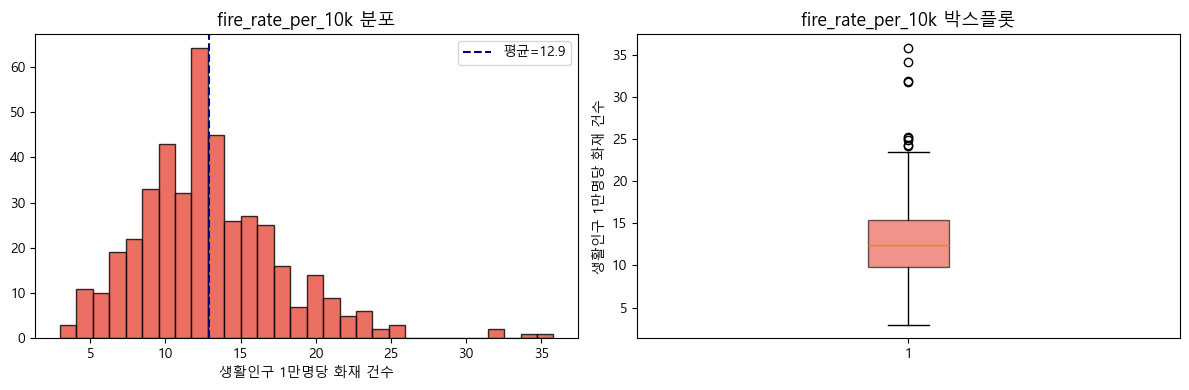

왜도: 0.985 | 첨도: 2.343


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, edgecolor='black', color='#e74c3c', alpha=0.8)
axes[0].set_title('fire_rate_per_10k 분포', fontsize=13)
axes[0].set_xlabel('생활인구 1만명당 화재 건수')
axes[0].axvline(y.mean(), color='navy', linestyle='--', label=f'평균={y.mean():.1f}')
axes[0].legend()

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops={'facecolor': '#e74c3c', 'alpha': 0.6})
axes[1].set_title('fire_rate_per_10k 박스플롯', fontsize=13)
axes[1].set_ylabel('생활인구 1만명당 화재 건수')

plt.tight_layout()
plt.savefig('../data/processed/eda_y_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'왜도: {y.skew():.3f} | 첨도: {y.kurtosis():.3f}')

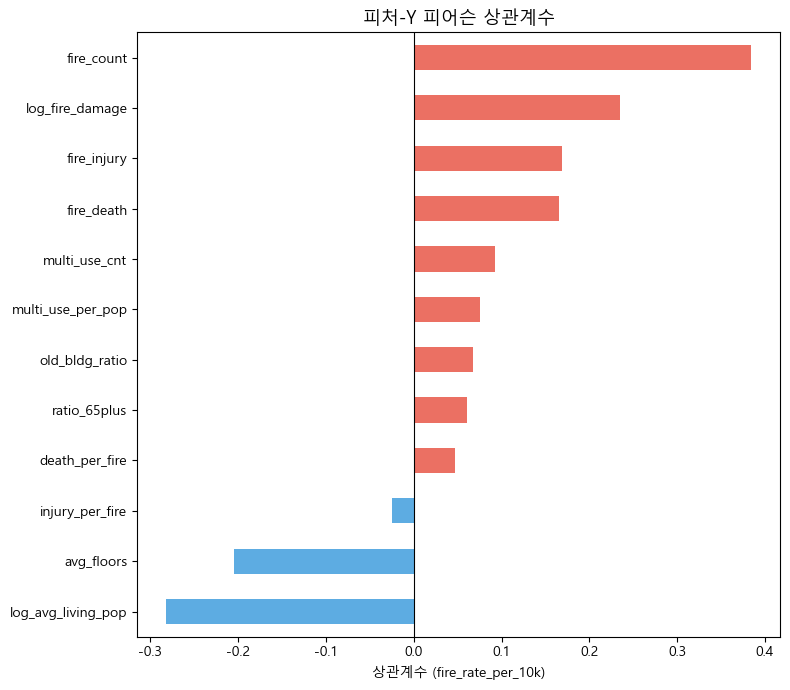

log_avg_living_pop   -0.282
avg_floors           -0.204
injury_per_fire      -0.024
death_per_fire        0.047
ratio_65plus          0.061
old_bldg_ratio        0.068
multi_use_per_pop     0.075
multi_use_cnt         0.093
fire_death            0.165
fire_injury           0.169
log_fire_damage       0.235
fire_count            0.384
dtype: float64


In [7]:
# 피처 상관계수
all_feats = list(set(FEAT_C))
corr_y = df[all_feats].corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_y]
corr_y.plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('피처-Y 피어슨 상관계수', fontsize=13)
ax.set_xlabel('상관계수 (fire_rate_per_10k)')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_y.round(3))

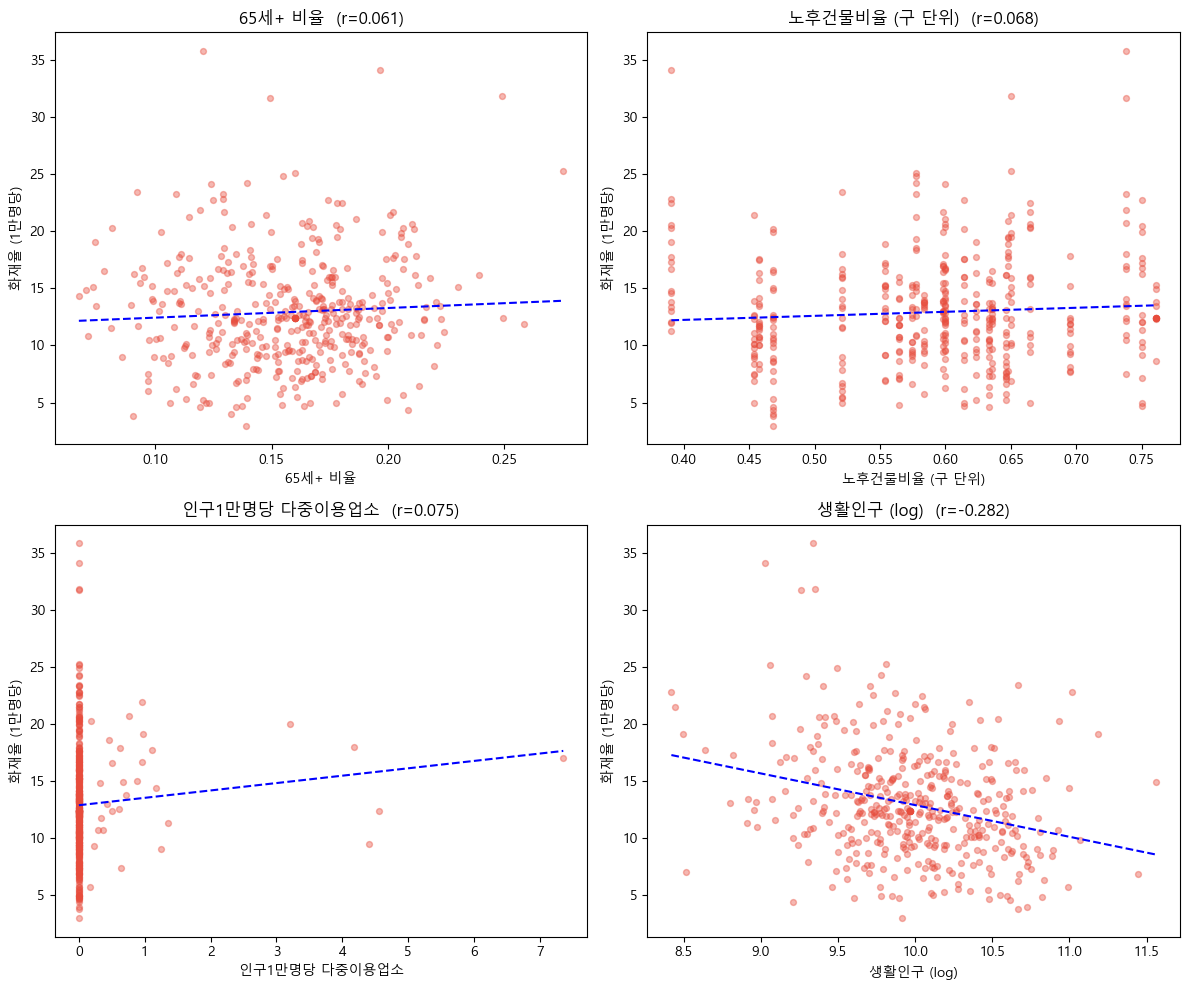

In [8]:
# 구조적 위험요인 4개 산점도
key_feats = ['ratio_65plus', 'old_bldg_ratio', 'multi_use_per_pop', 'log_avg_living_pop']
key_labels = ['65세+ 비율', '노후건물비율 (구 단위)', '인구1만명당 다중이용업소', '생활인구 (log)']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat, label in zip(axes.flatten(), key_feats, key_labels):
    ax.scatter(df[feat], y, alpha=0.4, s=18, color='#e74c3c')
    z = np.polyfit(df[feat], y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'b--', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('화재율 (1만명당)')
    corr_val = np.corrcoef(df[feat], y)[0, 1]
    ax.set_title(f'{label}  (r={corr_val:.3f})')

plt.tight_layout()
plt.savefig('../data/processed/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

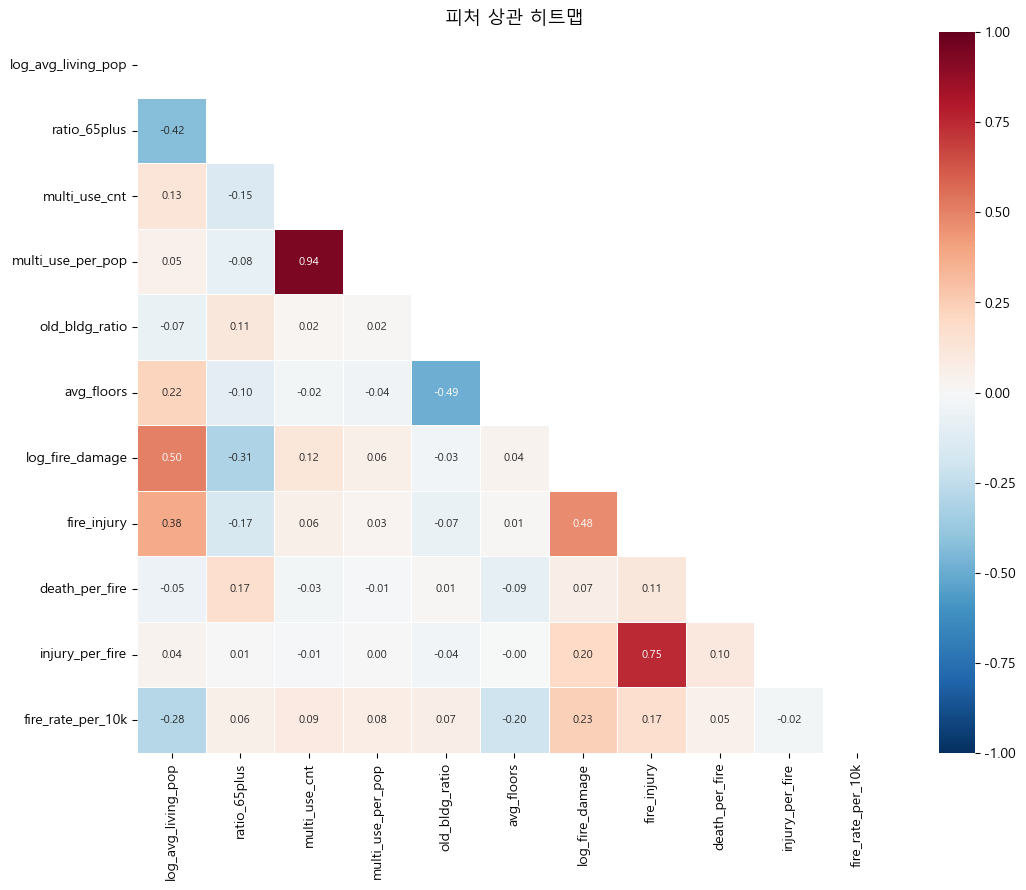

In [9]:
# 상관 히트맵 (FEAT_B)
corr = df[FEAT_B + ['fire_rate_per_10k']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('피처 상관 히트맵', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 피처셋 비교 (A / B / C)

In [10]:
def cv_eval(feats, label, n_splits=5):
    X = df[feats]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(df))
    for tr, val in kf.split(X):
        m = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3,
                                  max_features='sqrt', random_state=42, n_jobs=-1)
        m.fit(X.iloc[tr], y.iloc[tr])
        oof[val] = m.predict(X.iloc[val])
    r2   = r2_score(y, oof)
    rmse = np.sqrt(mean_squared_error(y, oof))
    mae  = mean_absolute_error(y, oof)
    print(f'[{label}] R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  features={len(feats)}')
    return r2, rmse, mae, oof

r2_a, rmse_a, mae_a, oof_a = cv_eval(FEAT_A, 'A 구조적위험요인')
r2_b, rmse_b, mae_b, oof_b = cv_eval(FEAT_B, 'B 구조적+과거피해')
r2_c, rmse_c, mae_c, oof_c = cv_eval(FEAT_C, 'C 전체이력')

[A 구조적위험요인] R²=0.1495  RMSE=4.4062  MAE=3.3313  features=6


[B 구조적+과거피해] R²=0.3006  RMSE=3.9956  MAE=3.0013  features=10


[C 전체이력] R²=0.5561  RMSE=3.1832  MAE=2.3314  features=12


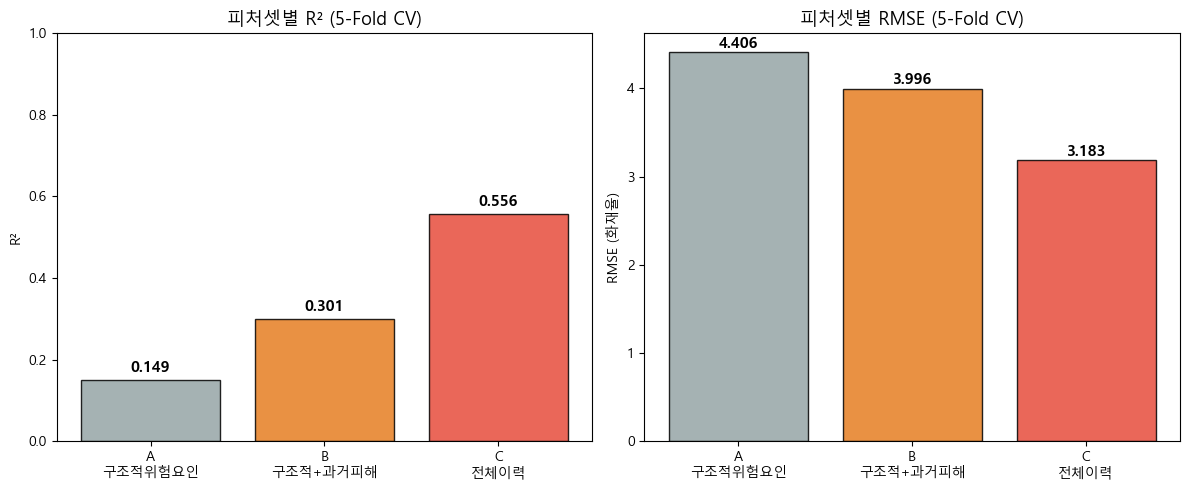

In [11]:
# 피처셋 비교 시각화
labels = ['A\n구조적위험요인', 'B\n구조적+과거피해', 'C\n전체이력']
r2_vals   = [r2_a, r2_b, r2_c]
rmse_vals = [rmse_a, rmse_b, rmse_c]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#95a5a6', '#e67e22', '#e74c3c']

bars = axes[0].bar(labels, r2_vals, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('피처셋별 R² (5-Fold CV)', fontsize=13)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for bar, v in zip(bars, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(labels, rmse_vals, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('피처셋별 RMSE (5-Fold CV)', fontsize=13)
axes[1].set_ylabel('RMSE (화재율)')
for bar, v in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/feature_set_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 최종 모델: B 피처셋 기반 Random Forest

과거 화재건수(fire_count)를 **제외**하고 구조적 취약성 + 피해 심각도로 예측.  
"현재 상태에서 어느 지역이 위험한가"를 진단하는 모델.

In [12]:
# 최종 모델: B 피처셋, 전체 데이터 학습
X_final = df[FEAT_B]

final_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_final, y)
print('최종 모델 학습 완료')

# 학습셋 R² (참고용)
train_pred = final_rf.predict(X_final)
print(f'학습셋 R²: {r2_score(y, train_pred):.4f}  (OOF R²: {r2_b:.4f})')

최종 모델 학습 완료
학습셋 R²: 0.7745  (OOF R²: 0.3006)


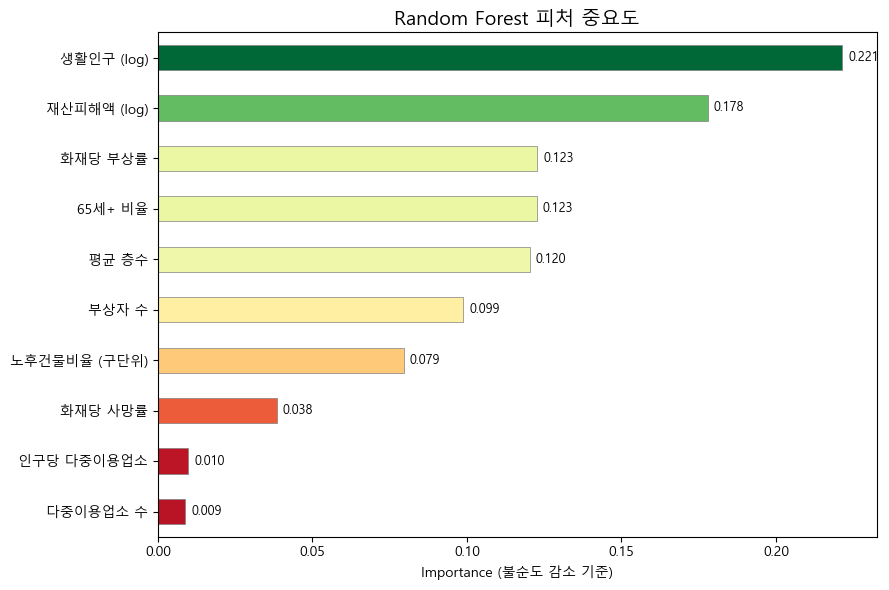

In [13]:
# 피처 중요도
feat_imp = pd.Series(final_rf.feature_importances_, index=FEAT_B).sort_values(ascending=True)

feat_labels = {
    'log_avg_living_pop': '생활인구 (log)',
    'ratio_65plus':       '65세+ 비율',
    'multi_use_cnt':      '다중이용업소 수',
    'multi_use_per_pop':  '인구당 다중이용업소',
    'old_bldg_ratio':     '노후건물비율 (구단위)',
    'avg_floors':         '평균 층수',
    'log_fire_damage':    '재산피해액 (log)',
    'fire_injury':        '부상자 수',
    'death_per_fire':     '화재당 사망률',
    'injury_per_fire':    '화재당 부상률',
}
feat_imp.index = [feat_labels.get(f, f) for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(9, 6))
cmap_vals = feat_imp.values / feat_imp.max()
colors = plt.cm.RdYlGn(cmap_vals)
bars = feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='gray', linewidth=0.5)
for i, v in enumerate(feat_imp):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_title('Random Forest 피처 중요도', fontsize=14)
ax.set_xlabel('Importance (불순도 감소 기준)')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

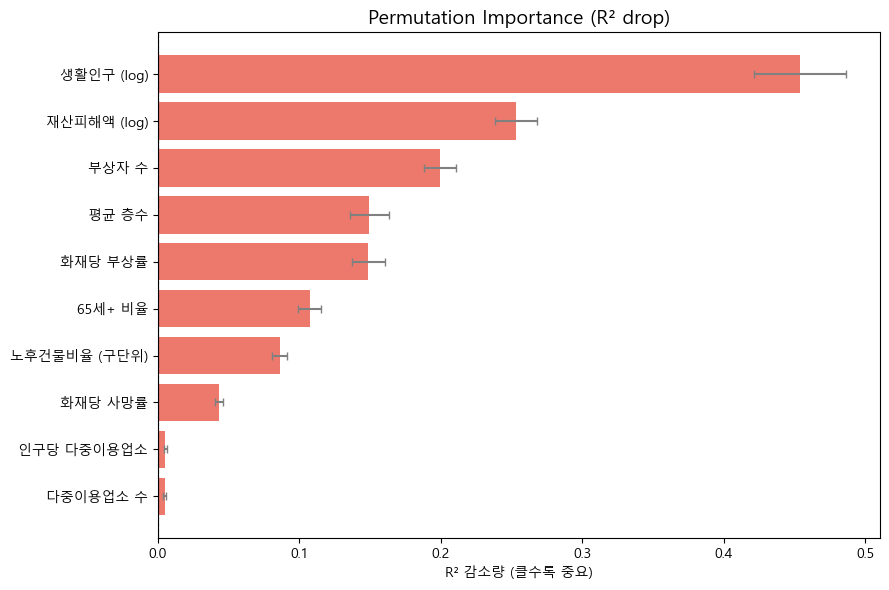

In [14]:
# Permutation Importance (과적합에 덜 민감)
perm = permutation_importance(final_rf, X_final, y, n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': [feat_labels.get(f, f) for f in FEAT_B],
    'mean': perm.importances_mean,
    'std':  perm.importances_std,
}).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['feature'], perm_df['mean'], xerr=perm_df['std'],
        color='#e74c3c', alpha=0.75, ecolor='gray', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Importance (R² drop)', fontsize=14)
ax.set_xlabel('R² 감소량 (클수록 중요)')
plt.tight_layout()
plt.savefig('../data/processed/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 예측 결과 분석

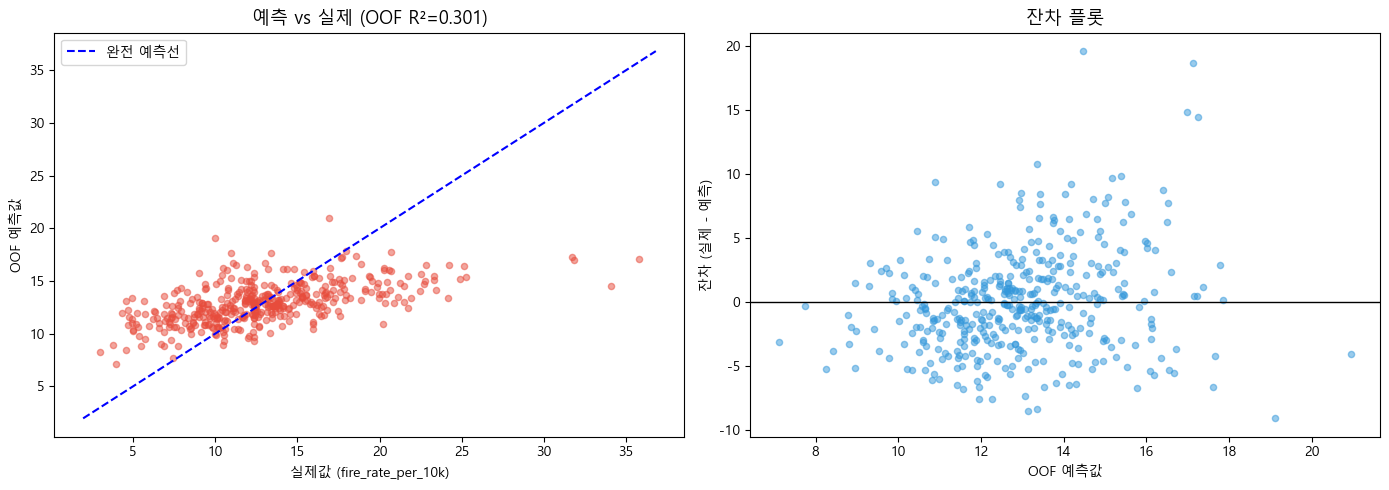

OOF RMSE: 3.9956  (Y 평균: 12.92  → 오차율: 30.9%)


In [15]:
# OOF 예측 (B 피처셋)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y, oof_b, alpha=0.5, s=20, color='#e74c3c')
lim = (y.min()-1, y.max()+1)
axes[0].plot(lim, lim, 'b--', linewidth=1.5, label='완전 예측선')
axes[0].set_xlabel('실제값 (fire_rate_per_10k)')
axes[0].set_ylabel('OOF 예측값')
axes[0].set_title(f'예측 vs 실제 (OOF R²={r2_b:.3f})', fontsize=13)
axes[0].legend()

residuals = y.values - oof_b
axes[1].scatter(oof_b, residuals, alpha=0.5, s=20, color='#3498db')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('OOF 예측값')
axes[1].set_ylabel('잔차 (실제 - 예측)')
axes[1].set_title('잔차 플롯', fontsize=13)

plt.tight_layout()
plt.savefig('../data/processed/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OOF RMSE: {rmse_b:.4f}  (Y 평균: {y.mean():.2f}  → 오차율: {rmse_b/y.mean()*100:.1f}%)')

## 6. 행정동별 위험도 스코어 산출

In [16]:
# 위험도 스코어 계산
pred = final_rf.predict(X_final)
pred_min, pred_max = pred.min(), pred.max()

df['pred_fire_rate'] = pred.round(4)
df['risk_score'] = ((pred - pred_min) / (pred_max - pred_min) * 9 + 1).round(2)

# 5단계 위험 등급
quintiles = np.percentile(df['risk_score'], [20, 40, 60, 80])
df['risk_grade'] = pd.cut(
    df['risk_score'],
    bins=[0, quintiles[0], quintiles[1], quintiles[2], quintiles[3], 10],
    labels=['매우낮음', '낮음', '보통', '높음', '매우높음'],
    include_lowest=True
)

print('위험 등급 분포 (각 20%):')
print(df['risk_grade'].value_counts().sort_index())

위험 등급 분포 (각 20%):
risk_grade
매우낮음    86
낮음      85
보통      85
높음      85
매우높음    85
Name: count, dtype: int64


In [17]:
# 상위 30 고위험 행정동
top30 = df[['adm_cd', 'adm_nm', 'risk_score', 'risk_grade',
            'fire_rate_per_10k', 'ratio_65plus', 'old_bldg_ratio', 'multi_use_cnt']]\
        .sort_values('risk_score', ascending=False).head(30)

pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
print('=== 상위 30 고위험 행정동 ===')
top30

=== 상위 30 고위험 행정동 ===


,adm_cd,adm_nm,risk_score,risk_grade,fire_rate_per_10k,ratio_65plus,old_bldg_ratio,multi_use_cnt
40,1117065000,서울특별시 용산구 이태원1동,10.000,매우높음,35.798,0.120,0.738,0.000
43,1117070000,서울특별시 용산구 보광동,9.190,매우높음,31.708,0.149,0.738,0.000
148,1132070000,서울특별시 도봉구 방학2동,8.930,매우높음,31.834,0.249,0.650,0.000
10,1111067000,서울특별시 종로구 창신1동,8.720,매우높음,34.101,0.197,0.391,0.000
24,1114065000,서울특별시 중구 신당5동,8.280,매우높음,25.135,0.160,0.578,0.000
155,1132052100,서울특별시 도봉구 도봉1동,7.720,매우높음,25.262,0.275,0.650,0.000
41,1117066000,서울특별시 용산구 이태원2동,7.710,매우높음,17.988,0.135,0.738,0.000
23,1114060500,서울특별시 중구 을지로동,7.650,매우높음,24.235,0.139,0.578,0.000
25,1114067000,서울특별시 중구 황학동,7.560,매우높음,24.893,0.155,0.578,0.000
8,1111063000,서울특별시 종로구 종로5·6가동,7.440,매우높음,22.512,0.178,0.391,0.000


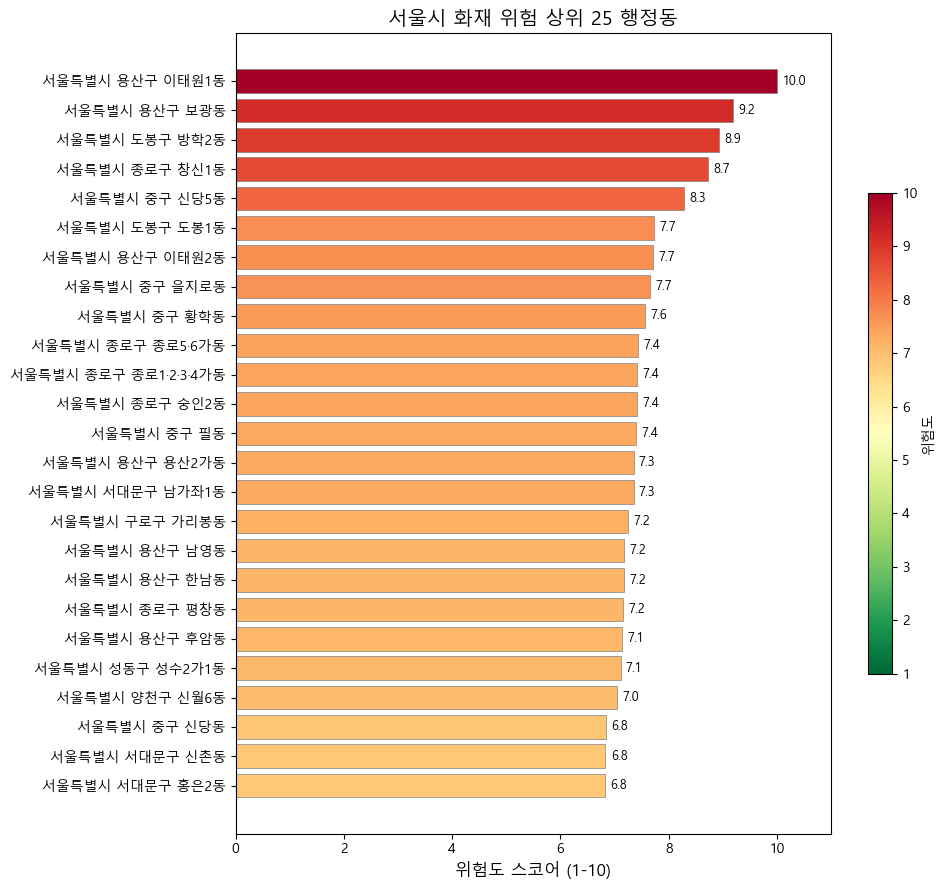

In [18]:
# 고위험 상위 25 시각화
top25 = df.sort_values('risk_score', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 9))
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=df['risk_score'].min(), vmax=df['risk_score'].max())
colors = [cmap(norm(s)) for s in top25['risk_score']]

bars = ax.barh(top25['adm_nm'][::-1], top25['risk_score'][::-1], color=colors[::-1], edgecolor='gray', linewidth=0.5)
ax.set_xlabel('위험도 스코어 (1-10)', fontsize=12)
ax.set_title('서울시 화재 위험 상위 25 행정동', fontsize=14)
ax.set_xlim(0, 11)
for bar, score in zip(bars, top25['risk_score'][::-1]):
    ax.text(score + 0.1, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='위험도', shrink=0.6)
plt.tight_layout()
plt.savefig('../data/processed/top25_risk.png', dpi=150, bbox_inches='tight')
plt.show()

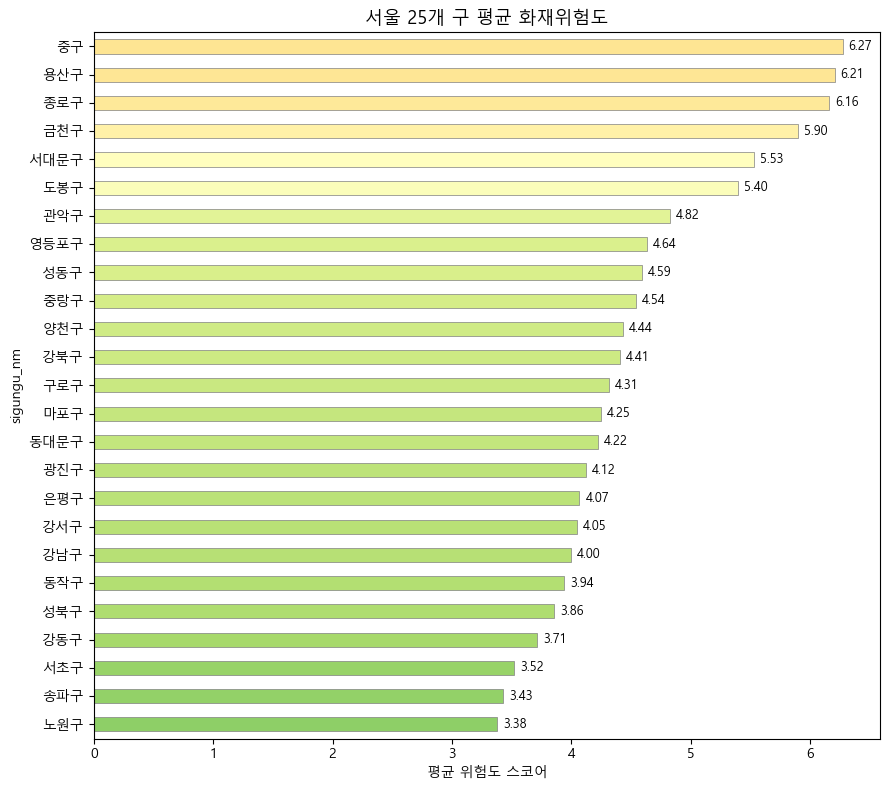

In [19]:
# 구별 평균 위험도
df['sigungu_cd'] = df['adm_cd'].str[:5]
sgg_map = {
    '11110':'종로구','11140':'중구','11170':'용산구','11200':'성동구',
    '11215':'광진구','11230':'동대문구','11260':'중랑구','11290':'성북구',
    '11305':'강북구','11320':'도봉구','11350':'노원구','11380':'은평구',
    '11410':'서대문구','11440':'마포구','11470':'양천구','11500':'강서구',
    '11530':'구로구','11545':'금천구','11560':'영등포구','11590':'동작구',
    '11620':'관악구','11650':'서초구','11680':'강남구','11710':'송파구','11740':'강동구'
}
df['sigungu_nm'] = df['sigungu_cd'].map(sgg_map)

sgg_risk = df.groupby('sigungu_nm')['risk_score'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors2 = [plt.cm.RdYlGn_r(norm(v)) for v in sgg_risk]
sgg_risk.plot(kind='barh', ax=ax, color=colors2, edgecolor='gray', linewidth=0.5)
ax.set_title('서울 25개 구 평균 화재위험도', fontsize=13)
ax.set_xlabel('평균 위험도 스코어')
for i, v in enumerate(sgg_risk):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/sgg_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 결과 저장

In [20]:
# 결과 CSV 저장
output_cols = [
    'adm_cd', 'adm_nm', 'sigungu_nm',
    'fire_rate_per_10k', 'pred_fire_rate', 'risk_score', 'risk_grade',
    'ratio_65plus', 'old_bldg_ratio', 'avg_floors',
    'multi_use_cnt', 'multi_use_per_pop',
    'avg_living_pop', 'avg_65plus_pop',
    'fire_count', 'fire_injury', 'fire_damage'
]
result_df = df[output_cols].sort_values('risk_score', ascending=False)
result_df.to_csv('../data/processed/risk_scores.csv', index=False, encoding='utf-8-sig')
print(f'저장: data/processed/risk_scores.csv  ({len(result_df)}개 행정동)')

# 모델 저장
with open('../models/rf_fire_risk.pkl', 'wb') as f:
    pickle.dump({
        'model': final_rf,
        'features': FEAT_B,
        'feat_labels': feat_labels,
        'oof_r2': r2_b,
        'oof_rmse': rmse_b,
    }, f)
print('모델 저장: models/rf_fire_risk.pkl')

저장: data/processed/risk_scores.csv  (426개 행정동)
모델 저장: models/rf_fire_risk.pkl


In [21]:
# 최종 요약
print('=' * 50)
print('         FireMap 모델 최종 결과 요약')
print('=' * 50)
print(f'학습 데이터   : 서울 {len(df)}개 행정동 (2021-2023)')
print(f'사용 피처     : {len(FEAT_B)}개 (구조적위험 + 피해심각도)')
print(f'모델          : RandomForest (n_estimators=500)')
print(f'OOF R²        : {r2_b:.4f}')
print(f'OOF RMSE      : {rmse_b:.4f} (Y평균 {y.mean():.2f}의 {rmse_b/y.mean()*100:.1f}%)')
print()
print(f'고위험 행정동 (상위 10%):')  
top10pct = df[df['risk_score'] >= df['risk_score'].quantile(0.9)][['adm_nm','risk_score']]\
           .sort_values('risk_score', ascending=False)
for _, row in top10pct.iterrows():
    print(f'  {row["adm_nm"]:15} {row["risk_score"]:.1f}')

         FireMap 모델 최종 결과 요약
학습 데이터   : 서울 426개 행정동 (2021-2023)
사용 피처     : 10개 (구조적위험 + 피해심각도)
모델          : RandomForest (n_estimators=500)
OOF R²        : 0.3006
OOF RMSE      : 3.9956 (Y평균 12.92의 30.9%)

고위험 행정동 (상위 10%):
  서울특별시 용산구 이태원1동 10.0
  서울특별시 용산구 보광동   9.2
  서울특별시 도봉구 방학2동  8.9
  서울특별시 종로구 창신1동  8.7
  서울특별시 중구 신당5동   8.3
  서울특별시 도봉구 도봉1동  7.7
  서울특별시 용산구 이태원2동 7.7
  서울특별시 중구 을지로동   7.7
  서울특별시 중구 황학동    7.6
  서울특별시 종로구 종로5·6가동 7.4
  서울특별시 종로구 숭인2동  7.4
  서울특별시 종로구 종로1·2·3·4가동 7.4
  서울특별시 중구 필동     7.4
  서울특별시 용산구 용산2가동 7.3
  서울특별시 서대문구 남가좌1동 7.3
  서울특별시 구로구 가리봉동  7.2
  서울특별시 용산구 한남동   7.2
  서울특별시 용산구 남영동   7.2
  서울특별시 종로구 평창동   7.2
  서울특별시 용산구 후암동   7.1
  서울특별시 성동구 성수2가1동 7.1
  서울특별시 양천구 신월6동  7.0
  서울특별시 중구 신당동    6.8
  서울특별시 서대문구 신촌동  6.8
  서울특별시 서대문구 홍은2동 6.8
  서울특별시 금천구 시흥5동  6.8
  서울특별시 성동구 마장동   6.8
  서울특별시 중구 광희동    6.7
  서울특별시 강남구 논현1동  6.6
  서울특별시 관악구 서원동   6.6
  서울특별시 종로구 삼청동   6.6
  서울특별시 서대문구 홍은1동 6.6
  서울특별시 중랑구 망우3동  6.6
  서울특별시 서대문구 연희동  6.6
  서울특별시 도봉구 창3동